A brief and simple implementation of deep hedging, inspired by the paper "Deep Hedging" by Hans Bühler, Lukas Gonon, Josef Teichmann, Ben Wood (https://arxiv.org/abs/1802.03042). Found in the review "A Review of New Developments in Finance with Deep Learning: Deep Hedging and Deep Calibration" by Yuji Shinozaki (https://www.imes.boj.or.jp/research/papers/english/24-E-02.pdf).

Note that I do not intend to write mathematically accurate.

We define first a convex risk measure as a risk measure $\rho: \mathcal X \to \mathbb R$ where $\mathcal X$ is the space of random variables on our state space $\Omega$ that satisfies

1. Monotonic Decrease: For $X_1, X_2 \in \mathcal X$, if $X_1 \geq X_2$, then $\rho(X_1) \leq \rho(X_2)$.
2. Convexity: For $\alpha \in [0, 1]$ and $X_1, X_2 \in \mathcal X$, $\rho(\alpha X_1 + (1-\alpha) X_2) \leq \alpha \rho(X_1) + (1-\alpha) \rho(X_2)$.
3. Cash invariance: For $X \in \mathcal X$ and $c \in \mathbb R$, $\rho(X + c) = \rho(X) -c$.

A convex risk measure is meant to be (as the name suggests) a measure of risk (why its defined how it is defined is intuitive but I will not mention it). But what are the random variables used as inputs for such a risk measure? In the case of hedging, we care about P&L. Consider a stochastic process $\{\delta_k\}_{k=0,1,\ldots n}$ which makes up our hedging strategy for a European call option with strike $K$ and so has the payoff $Z_T = (S_T - K)^+$. The $\delta_k$ process decides how much of the underlying $S_t$ we hold at time $t=k+1$, we assume that the transaction costs are proportional to the volume of the transaction by some constant $\epsilon$, so that the transaction cost at time $k$ is $\epsilon |\delta_k - \delta_{k-1}| S_k$. Given the current price $p_0$ of the option, the P&L is then

$$\text{PL}^{(Z_T, p_0, \delta)} = p_0 - Z_T + \sum_{k=0}^{n-1}\delta_k(S_{k+1} - S_k) - \sum_{k=0}^{n}\epsilon |\delta_k - \delta_{k-1}| S_k.$$

Our goal is to minimize the risk of the risk measure of the P&L, since this means we have minimized the uncertainty between the hedging portfolio (minus transaction costs) and the instrument we are hedging, i.e. replicating it as good as we can. For this purpose we define the minimized hedging process given $Z_T$ (which is a simple European in our first case but can be whatever random variable you want) and the initial price $p_0$, as $$\pi(Z_T, p_0) = \min_\delta \rho(\text{PL}^{(Z_T, p_0, \delta)}).$$

Pricing in a frictionless world is easy, with friction and transaction costs it becomes not easy. The so called \textit{utility-indifference price} is often used in cases with "friction", it is defined as the price $p_0^*$ where $$\pi(Z_T, p_0^*) = \pi(0, 0).$$

By the previously mentioned properties of a convex risk measure one can easily show that $p_0^*$ satisfies $$p_0^* = \pi(Z_T, 0) - \pi(0,0).$$

In order to find $\pi(Z_T, 0)$, we will use neural networks and train on simple GBM paths, with $\sigma = 0.2, r = 0$, as the underlying of a European call option.

We will use $dt = \frac{1}{365}$, $t = 0, \ldots, n$ with $n=30$. We will use one distinct NN for each timestep, so in total we will have $n=30$ NNs denoted by $F^{k}$, where $k=0,\ldots, n-1$. The inputs to $F^{k}$ will be the current price and the previous hedge: $(S_t, \delta_{t-1})$, the output is the next hedge: $\delta_t$. For $t=0$ we set the "previous hedge" to zero. Each NN looks the same and has the structure (two hidden layers, LayerNorm and ReLu, 2 inputs one output):

Linear(2, 16) $\to$ LayerNorm(16) $\to$ ReLu $\to$ Linear(16, 16) $\to$ LayerNorm(16) $\to$ ReLu $\to$ Linear(16, 16) $\to$ LayerNorm(16) $\to$ ReLu $\to$ Linear(16, 1)



The loss function used is the convex risk measure of the P&L. We use the entropic risk measure (the paper also uses CVaR/Expected Shortfall which you can put on a cool form to work as a NN loss function, but we do not use it here even though I have implemented it). The entropic risk measure, given the risk aversion parameter $\lambda$ is $$\rho(X) = \frac{1}{\lambda} \ln \mathbb E [\exp (-\lambda X)].$$

Thus our loss function given the parameters $\theta = \theta_0, \ldots, \theta_{n-1}$ where $\theta_k$ are the parameters for $F^k$, is (we use $p_0 = 0$ for the tuning)

$$J(\theta) = \rho_{\text{Entropic}}(\{\text{PL}^{Z_T, 0, \delta^\theta}(\omega_i)\}_{i=i,\ldots, N}).$$

Here $\omega_i$ for $i=1,\ldots, N$ represent $N$ scenarios of the underlying $S_t$ process, we use $N = 8192 = 2^13$. One epoch of training this NN thus looks like the following (I use the ADAM optimizer with starting lr=5e-5):

1. Simulate N GBM paths $\{S_{t,i}\}_{i=1,\ldots, N}$ which each give the terminal payoff $Z_{T, i}$ for the option.
2. For each path, calculate $\{\delta_{k,i}^{\theta}\}$ by $$\delta_{0, i}^{\theta} = F^0(S_0, 0; \theta_0)$$ $$\delta_{k,i}^\theta = F^k(S_k, \delta_{i, k-1}^\theta; \theta_k)\quad (k=1,\ldots, n-1)$$
3. For each path calculate $$\text{PL}_i^{(Z_{T, i}, 0, \delta_{k,i}^\theta)} = \text{PL}_i^\theta.$$
4. Calculate $$J(\theta) = \rho(\text{PL}^\theta) \approx \frac{1}{\lambda} \ln \frac{1}{N} \sum_{i=1}^N \exp (-\lambda \text{PL}_i^\theta).$$
5. Backpropagate with the optimizer.

We start by importing things and defining helper functions, we will compare the results with Whalley-Wilmott's hedging strategy (with $\lambda = 1$), which is a hedging strategy that considers transaction costs.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

S0      = 100
sigma   = 0.2
K       = 100
n_steps = 30
dt      = 1 / 365
T       = n_steps * dt
lam     = 1


def bs_price(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * scipy.stats.norm.cdf(d1) - K * np.exp(-r * T) * scipy.stats.norm.cdf(d2)


def bs_delta(S, K, T_remaining, r, sigma):
    if T_remaining <= 0:
        return np.where(S > K, 1.0, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T_remaining) / (sigma * np.sqrt(T_remaining))
    return scipy.stats.norm.cdf(d1)


def discrete_delta_hedge_PL(S_batch, epsilon=0.0, r=0.0):
    S = S_batch  # (N, n_steps)
    N = S.shape[0]
    delta = np.zeros((N, n_steps))

    for t in range(n_steps):
        T_rem = (n_steps - t) * dt
        delta[:, t] = bs_delta(S[:, t], K, T_rem, r, sigma)

    stock_PL = (delta[:, :-1] * (S[:, 1:] - S[:, :-1])).sum(1)
    tc = epsilon * np.abs(delta[:, 0]) * S[:, 0]
    tc += (epsilon * np.abs(delta[:, 1:] - delta[:, :-1]) * S[:, 1:]).sum(1)
    payoff = np.maximum(S[:, -1] - K, 0)
    return -payoff + stock_PL - tc


def generate_paths(N):
    W = np.random.normal(size=(N, n_steps)) * np.sqrt(dt)
    log_S = np.cumsum(
        np.hstack([np.zeros((N, 1)), -0.5 * sigma**2 * dt + sigma * W[:, :-1]]),
        axis=1
    )
    return torch.tensor(S0*np.exp(log_S), dtype=torch.float32)


def build_nn():
    return torch.nn.Sequential(
        torch.nn.Linear(2, 16), torch.nn.LayerNorm(16), torch.nn.ReLU(),
        torch.nn.Linear(16, 16), torch.nn.LayerNorm(16), torch.nn.ReLU(),
        torch.nn.Linear(16, 16), torch.nn.LayerNorm(16), torch.nn.ReLU(),
        torch.nn.Linear(16, 1),
    )


def compute_PL(S_batch, NN_list, epsilon):
    N = S_batch.shape[0]
    delta = torch.zeros(N, n_steps)

    for t in range(n_steps):
        prev = delta[:, t - 1] if t > 0 else torch.zeros(N)
        inp  = torch.stack([torch.log(S_batch[:, t] / K), prev], dim=1)
        delta[:, t] = NN_list[t](inp).squeeze(1)

    stock_PL = (delta[:, :-1] * (S_batch[:, 1:] - S_batch[:, :-1])).sum(1)
    tc = epsilon * delta[:, 0].abs() * S_batch[:, 0]
    tc = tc + (epsilon * (delta[:, 1:] - delta[:, :-1]).abs() * S_batch[:, 1:]).sum(1)
    Z  = (S_batch[:, -1] - K).clamp(min=0)
    return -Z + stock_PL - tc

def bs_gamma(S, t, K, sigma, T):
    tau = T - t
    if tau < 1e-10:
        return 0.0
    d1 = (np.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    return scipy.stats.norm.pdf(d1) / (S * sigma * np.sqrt(tau))

def compute_PL_whalley_wilmott(S_batch, epsilon, lam=1):
    S_np = S_batch.numpy() if isinstance(S_batch, torch.Tensor) else S_batch
    N = S_np.shape[0]
    delta = np.zeros((N, n_steps))

    for t in range(n_steps):
        S_t = S_np[:, t]
        tau = (n_steps - t) * dt
        delta_bs = bs_delta(S_t, K, tau, r=0, sigma=sigma)
        gamma_bs = bs_gamma(S_t, t * dt, K, sigma, T)

        if t == 0:
            delta[:, t] = delta_bs
        else:
            prev = delta[:, t - 1]
            bandwidth = (1.5 * lam * epsilon * sigma**2 * S_t**2 * np.abs(gamma_bs)) ** (1/3)
            needs_trade = np.abs(prev - delta_bs) > bandwidth
            delta[:, t] = np.where(needs_trade, delta_bs, prev)

    delta_t = torch.tensor(delta, dtype=torch.float32)
    S_t = torch.tensor(S_np, dtype=torch.float32)
    stock_PL = (delta_t[:, :-1] * (S_t[:, 1:] - S_t[:, :-1])).sum(1)
    tc = epsilon * delta_t[:, 0].abs() * S_t[:, 0]
    tc = tc + (epsilon * (delta_t[:, 1:] - delta_t[:, :-1]).abs() * S_t[:, 1:]).sum(1)
    Z = (S_t[:, -1] - K).clamp(min=0)
    return -Z + stock_PL - tc


def entropic_risk(PL):
    x = -lam * PL
    m = x.max().detach()
    return (1 / lam) * (m + torch.log(torch.exp(x - m).mean()))

Then we train the NNs, remember that $\epsilon$ decided the transaction costs. I use a Plateau scheduler, not sure if it helps at all. The training takes a couple minutes, I have not moved anything to the GPU.

In [7]:
N_train  = 8192
N_valid  = 500_000
n_epochs = 2000
epsilon = 0.001

print(f"\n=== epsilon = {epsilon:.4f} ===")
NN_list   = [build_nn() for _ in range(n_steps)]
optimizer = torch.optim.Adam(
    [p for nn in NN_list for p in nn.parameters()], lr=5e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=150, factor=0.5, min_lr=1e-7
)

for epoch in range(n_epochs):
    S = generate_paths(N_train)
    optimizer.zero_grad()
    loss = entropic_risk(compute_PL(S, NN_list, epsilon))
    loss.backward()
    optimizer.step()
    scheduler.step(loss.detach())
    if epoch % 200 == 0:
        print(f"    epoch {epoch:4d}  loss={loss.item():.7f}")


=== epsilon = 0.0010 ===
    epoch    0  loss=20.5747681
    epoch  200  loss=3.1223221
    epoch  400  loss=2.6455851
    epoch  600  loss=2.5455489
    epoch  800  loss=2.5187576
    epoch 1000  loss=2.5259442
    epoch 1200  loss=2.5238190
    epoch 1400  loss=2.5143175
    epoch 1600  loss=2.5059059
    epoch 1800  loss=2.5134411


Then we plot the results, both as a PL histogram PDF, and also by comparing the hedging portfolio to the option price and to the Whalley-Wilmott strategy.

WW hedge: 2.741313934326172
Deep hedge: 2.5077993869781494


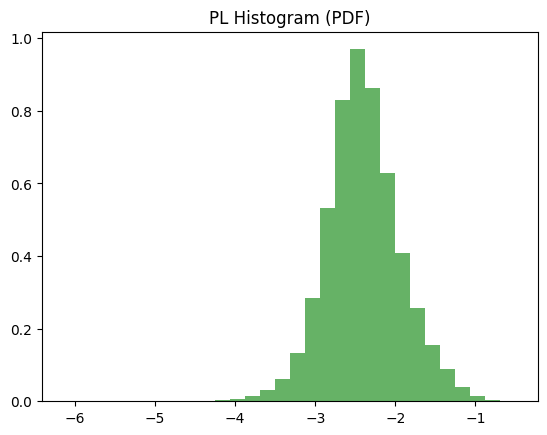

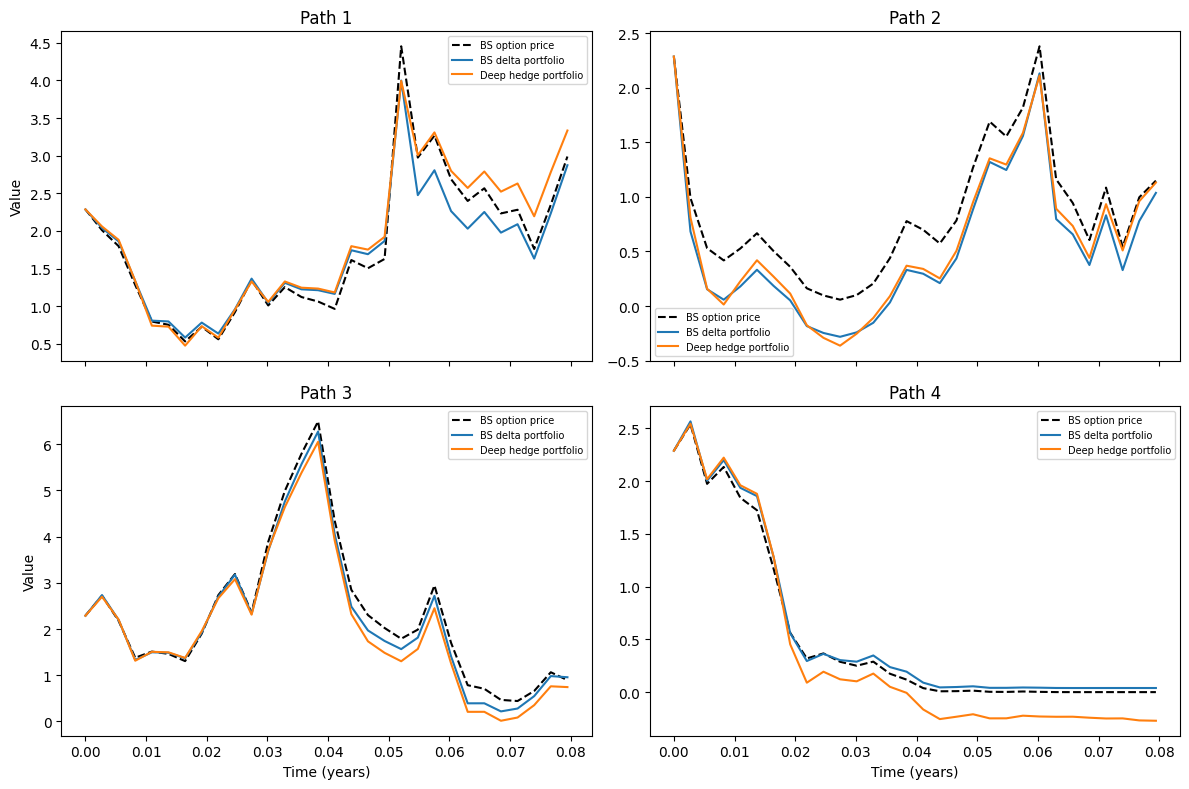

In [8]:
with torch.no_grad():
        S_val = generate_paths(N_valid)
        PL_val = compute_PL(S_val, NN_list, epsilon)
        PL_bs = compute_PL_whalley_wilmott(S_val, epsilon=epsilon)
    
print(f"WW hedge: {entropic_risk(PL_bs)}")
print(f"Deep hedge: {entropic_risk(PL_val)}")

plt.hist(PL_val.detach().cpu().numpy(), bins=30, density=True, alpha=0.6, color='g')
plt.title("PL Histogram (PDF)")
plt.show()

times = np.arange(n_steps) * dt

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for i, ax in enumerate(axes.flat):
    with torch.no_grad():
        S1 = generate_paths(1)
        dh_delta = torch.zeros(1, n_steps)
        for t in range(n_steps):
            prev = dh_delta[:, t - 1] if t > 0 else torch.zeros(1)
            inp  = torch.stack([torch.log(S1[:, t] / K), prev], dim=1)
            dh_delta[:, t] = NN_list[t](inp).squeeze(1)
        dh_delta_np = dh_delta[0].numpy()

        S1_np = S1[0].numpy()
        bs_delta_path = np.array([bs_delta(S1_np[t], K, (n_steps - t) * dt, 0, sigma) for t in range(n_steps)])
        bs_price_path = np.array([bs_price(S1_np[t], K, max((n_steps - t) * dt, 1e-10), 0, sigma) for t in range(n_steps)])

    premium = bs_price(S1_np[0], K, T, 0, sigma)
    bs_portfolio = premium + np.concatenate([[0], np.cumsum(bs_delta_path[:-1] * np.diff(S1_np))])
    dh_portfolio = premium + np.concatenate([[0], np.cumsum(dh_delta_np[:-1]  * np.diff(S1_np))])

    ax.plot(times, bs_price_path, label='BS option price', color='black', linestyle='--')
    ax.plot(times, bs_portfolio,  label='BS delta portfolio')
    ax.plot(times, dh_portfolio,  label='Deep hedge portfolio')
    ax.set_title(f'Path {i+1}')
    ax.legend(fontsize=7)
    if i >= 2:
        ax.set_xlabel('Time (years)')
    if i % 2 == 0:
        ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

On some paths it performs good on some paths it performs worse! In general it seems quite fine.

There is apparently also a theoretical result (for the continuous trading assumption) that says that, at least for the entropic risk measure, $p_\epsilon - p_0 \sim \mathcal O(\epsilon^{2/3})$. This can also be tested and is tested in the Buehler paper. To do this we use the BS price as $p_0$ and train NNs for several epsilons. I use a scale similar to Buehler's paper. First the training, just to show the analysis I am doing quite small batches, points, and epochs.

In [17]:
p0_bs = bs_price(S0, K, T, r=0, sigma=sigma)
print(f"BS price p0 = {p0_bs:.5f}")

N_train  = 2**10
N_valid  = 500_000
n_epochs = 1000

M = 4
epsilons = np.logspace(-3.5, -1, M)

indiff_prices = []

for eps in epsilons:
    print(f"\n=== epsilon = {eps:.4f} ===")
    NN_list   = [build_nn() for _ in range(n_steps)]
    optimizer = torch.optim.Adam(
        [p for nn in NN_list for p in nn.parameters()], lr=5e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=150, factor=0.5, min_lr=1e-7
    )

    for epoch in range(n_epochs):
        S = generate_paths(N_train)
        optimizer.zero_grad()
        loss = entropic_risk(compute_PL(S, NN_list, eps))
        loss.backward()
        optimizer.step()
        scheduler.step(loss.detach())
        if epoch % 200 == 0:
            print(f"    epoch {epoch:4d}  loss={loss.item():.7f}")

    with torch.no_grad():
        S_val = generate_paths(N_valid)
        p_eps = entropic_risk(compute_PL(S_val, NN_list, eps)).item()

    diff = p_eps - p0_bs
    print(f"  p_eps={p_eps:.5f}  p0_bs={p0_bs:.5f}  diff={diff:.5f}")
    indiff_prices.append(p_eps)

BS price p0 = 2.28715

=== epsilon = 0.0003 ===
    epoch    0  loss=18.1864128
    epoch  200  loss=3.8152986
    epoch  400  loss=2.5523915
    epoch  600  loss=2.4830689
    epoch  800  loss=2.4981518
  p_eps=2.46679  p0_bs=2.28715  diff=0.17964

=== epsilon = 0.0022 ===
    epoch    0  loss=17.7064705
    epoch  200  loss=4.6562133
    epoch  400  loss=2.8854730
    epoch  600  loss=2.7522418
    epoch  800  loss=2.7830608
  p_eps=2.70801  p0_bs=2.28715  diff=0.42086

=== epsilon = 0.0147 ===
    epoch    0  loss=30.3176346
    epoch  200  loss=5.0522504
    epoch  400  loss=5.5355320
    epoch  600  loss=5.0190096
    epoch  800  loss=4.9635940
  p_eps=5.01479  p0_bs=2.28715  diff=2.72764

=== epsilon = 0.1000 ===
    epoch    0  loss=145.9161224
    epoch  200  loss=21.3030148
    epoch  400  loss=12.2064075
    epoch  600  loss=12.2158689
    epoch  800  loss=10.5991411
  p_eps=13.28437  p0_bs=2.28715  diff=10.99722


Then we fit a regression to the points $(\log \epsilon, p_\epsilon - p_0)$ as well as plot a line with exponent 2/3.


Fitted exponent k = 0.7407  (theory: 2/3 ≈ 0.6667)


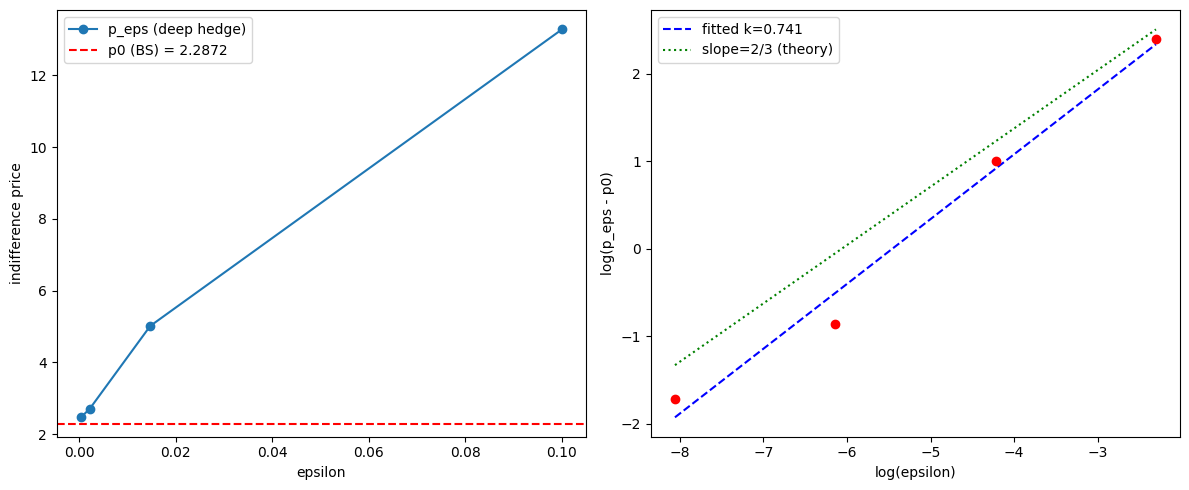

In [18]:
eps_arr   = np.array(epsilons)
price_arr = np.array(indiff_prices)
diff_arr  = price_arr - p0_bs

mask     = diff_arr > 0
log_eps  = np.log(eps_arr[mask])
log_diff = np.log(diff_arr[mask])
k, log_C = np.polyfit(log_eps, log_diff, 1)
C = np.exp(log_C)
print(f"\nFitted exponent k = {k:.4f}  (theory: 2/3 ≈ 0.6667)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(eps_arr, price_arr, 'o-', label='p_eps (deep hedge)')
axes[0].axhline(p0_bs, color='r', linestyle='--', label=f'p0 (BS) = {p0_bs:.4f}')
axes[0].set_xlabel('epsilon')
axes[0].set_ylabel('indifference price')
axes[0].legend()

axes[1].scatter(log_eps, log_diff, color='red', zorder=5)
axes[1].plot(log_eps, k * log_eps + log_C, 'b--', label=f'fitted k={k:.3f}')
axes[1].plot(log_eps, (2/3) * log_eps + log_C, 'g:', label='slope=2/3 (theory)')
axes[1].set_xlabel('log(epsilon)')
axes[1].set_ylabel('log(p_eps - p0)')
axes[1].legend()

plt.tight_layout()
plt.savefig('main_result.png', dpi=150)
plt.show()

Even with quite few points and too few epochs and too small batches, 0.741 is almost 2/3.